# Extract, modify, and write attribute data in vector datasets

Vector datasets combine geometries with attribute data stored in a table-like structure.
This example shows how to extract, insert, and modify attribute data in vector datasets to prepare them for further analysis. For instance, it calculates the area of all federal states in Germany and adds a random levelized cost of electricity to each state.

**Import required packages**

GeoKit is imported to provide the required functionality for working with vector data.


In [15]:
import geokit.core.vector
import geokit.core.geom
import geokit.core.srs
import numpy as np
import pandas as pd
import pathlib
from geokit.core.get_test_data import get_test_data

In [16]:
# Path to cache folder
data_cache_folder = pathlib.Path().cwd().parent.parent.joinpath("geokit", "data")

# Path to shapefile folder
path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)

# Load vector dataset from a Shapefile as a pandas DataFrame and reproject to EPSG:3035
data_frame_germany = geokit.core.vector.extractFeatures(path_to_shape_file, srs=3035)

**Add attributes to the vector dataset**

In [17]:
# Add average LCOE column with random values

# Generate random LCOE values for each row
n_rows = data_frame_germany.loc[:, "geom"].shape[0]
lcoe_values = np.random.uniform(low=30.0, high=80.0, size=n_rows)

In [18]:
# Calculate the size of each geometry (area)
areas_m2 = data_frame_germany.loc[:, "geom"].apply(lambda g: g.GetArea())

# Add new column (LCOE and area)to the vector dataset
data_frame_germany.loc[:, "avg_LCOE"] = pd.Series(lcoe_values)
data_frame_germany.loc[:, "area_km2"] = pd.Series(areas_m2 / 1e6)

# Show updated dataset
data_frame_germany

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,avg_LCOE,area_km2
0,MULTIPOLYGON (((4223953.58970637 2731509.51891...,DEU,Germany,DEU.1_1,Baden-Württemberg,None,None,Land,State,08,DE.BW,58.308129,36074.255068
1,"POLYGON ((4301467.52857983 2715580.87627153,43...",DEU,Germany,DEU.2_1,Bayern,Bavaria,None,Freistaat,None,09,DE.BY,61.401387,70544.892566
2,"POLYGON ((4536790.77005341 3258960.86848328,45...",DEU,Germany,DEU.3_1,Berlin,None,None,Land,State,11,DE.BE,78.664846,891.862007
3,MULTIPOLYGON (((4475872.02032226 3238148.49116...,DEU,Germany,DEU.4_1,Brandenburg,None,None,Land,State,12,DE.BR,67.395945,29654.223234
4,MULTIPOLYGON (((4234577.75904604 3327007.62237...,DEU,Germany,DEU.5_1,Bremen,None,None,Freie Hansestadt,State,04,DE.HB,71.284506,399.805154
5,MULTIPOLYGON (((4334970.2892255 3379166.259019...,DEU,Germany,DEU.6_1,Hamburg,None,None,Freie und Hansestadt,State,02,DE.HH,50.960946,736.380193
6,MULTIPOLYGON (((4225654.7277815 2946381.549486...,DEU,Germany,DEU.7_1,Hessen,Hesse,None,Land,State,06,DE.HE,52.783023,21115.145261
7,MULTIPOLYGON (((4419026.73328481 3437109.38907...,DEU,Germany,DEU.8_1,Mecklenburg-Vorpommern,Mecklenburg-West Pomerania,None,Land,State,13,DE.MV,38.665755,23376.544328
8,MULTIPOLYGON (((4106781.29483516 3394915.76735...,DEU,Germany,DEU.9_1,Niedersachsen,Lower Saxony,None,Land,State,03,DE.NI,63.643872,47672.270673
9,"POLYGON ((4183914.44196412 3066634.81647491,41...",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW,70.801383,34115.675424


**Inspect attributes**

In [19]:
data_frame_germany[["avg_LCOE", "area_km2"]].describe()

,avg_LCOE,area_km2
count,16.000000,16.000000
mean,61.250323,22364.959365
std,12.404560,18717.109604
min,33.188524,399.805154
25%,56.926852,12364.254140
50%,62.538820,20204.379452
75%,69.451635,30769.586282
max,78.664846,70544.892566


**Filter attributes**

In [20]:
# Select regions with low average LCOE
low_cost_regions = data_frame_germany[data_frame_germany["avg_LCOE"] < 50]

# Show selected regions
print("Regions with low average LCOE (< 50):")
print(low_cost_regions["NAME_1"])


# Select regions higher than average area size
average_area = data_frame_germany["area_km2"].mean()

large_regions = data_frame_germany[data_frame_germany["area_km2"] > average_area]

# Show selected regions
print("")
print("Regions with area larger than average:")
print(large_regions["NAME_1"])

Regions with low average LCOE (< 50):
7     Mecklenburg-Vorpommern
14        Schleswig-Holstein
Name: NAME_1, dtype: object

Regions with area larger than average:
0         Baden-Württemberg
1                    Bayern
3               Brandenburg
7    Mecklenburg-Vorpommern
8             Niedersachsen
9       Nordrhein-Westfalen
Name: NAME_1, dtype: object


In [21]:
# Add average LCOE column with random values

# Generate random LCOE values for each row
n_rows = data_frame_germany.geom.shape[0]
lcoe_values = np.random.uniform(low=30.0, high=80.0, size=n_rows)

# Calculate the size of each geometry (area)
areas_m2 = data_frame_germany.geom.apply(lambda g: g.GetArea())

# Add new column (LCOE and area)to the vector dataset
data_frame_germany["avg_LCOE"] = pd.Series(lcoe_values)
data_frame_germany["area_km2"] = pd.Series(areas_m2 / 1e6)

# Show updated dataset
data_frame_germany

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,avg_LCOE,area_km2
0,MULTIPOLYGON (((4223953.58970637 2731509.51891...,DEU,Germany,DEU.1_1,Baden-Württemberg,None,None,Land,State,08,DE.BW,72.485000,36074.255068
1,"POLYGON ((4301467.52857983 2715580.87627153,43...",DEU,Germany,DEU.2_1,Bayern,Bavaria,None,Freistaat,None,09,DE.BY,31.644759,70544.892566
2,"POLYGON ((4536790.77005341 3258960.86848328,45...",DEU,Germany,DEU.3_1,Berlin,None,None,Land,State,11,DE.BE,67.577253,891.862007
3,MULTIPOLYGON (((4475872.02032226 3238148.49116...,DEU,Germany,DEU.4_1,Brandenburg,None,None,Land,State,12,DE.BR,65.256347,29654.223234
4,MULTIPOLYGON (((4234577.75904604 3327007.62237...,DEU,Germany,DEU.5_1,Bremen,None,None,Freie Hansestadt,State,04,DE.HB,79.068189,399.805154
5,MULTIPOLYGON (((4334970.2892255 3379166.259019...,DEU,Germany,DEU.6_1,Hamburg,None,None,Freie und Hansestadt,State,02,DE.HH,67.553914,736.380193
6,MULTIPOLYGON (((4225654.7277815 2946381.549486...,DEU,Germany,DEU.7_1,Hessen,Hesse,None,Land,State,06,DE.HE,39.300491,21115.145261
7,MULTIPOLYGON (((4419026.73328481 3437109.38907...,DEU,Germany,DEU.8_1,Mecklenburg-Vorpommern,Mecklenburg-West Pomerania,None,Land,State,13,DE.MV,34.536613,23376.544328
8,MULTIPOLYGON (((4106781.29483516 3394915.76735...,DEU,Germany,DEU.9_1,Niedersachsen,Lower Saxony,None,Land,State,03,DE.NI,59.381620,47672.270673
9,"POLYGON ((4183914.44196412 3066634.81647491,41...",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW,41.253828,34115.675424


### Visualizing vector attributes

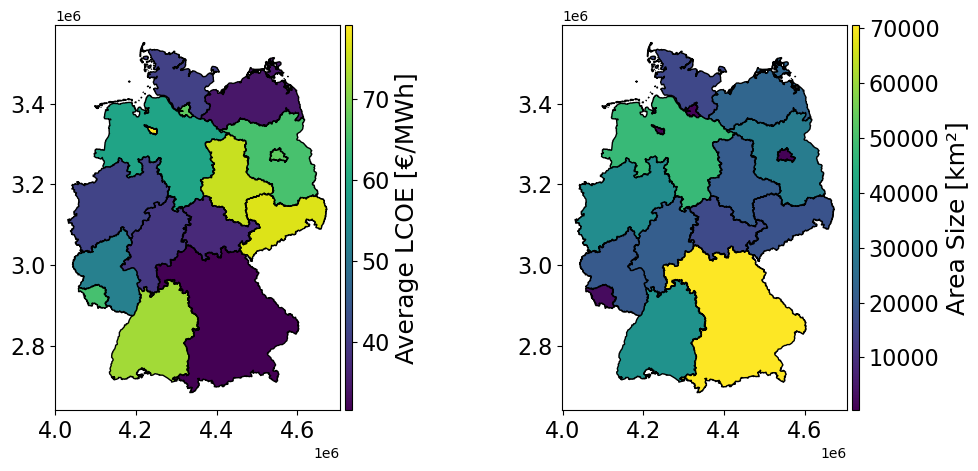

In [ ]:
# colored by LCOE
import matplotlib.pyplot as plt

# Create two subplots for side-by-side comparison
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax_handle_lcoe = geokit.core.geom.drawGeoms(
    data_frame_germany,
    colorBy="avg_LCOE",
    srs=3035,
    figsize=(6, 4),
    draw_cbar=True,
    cbarTitle="Average LCOE [€/MWh]",
    ax=ax[0],
)

# colored by area Size

ax_handle_area = geokit.core.geom.drawGeoms(
    data_frame_germany,
    colorBy="area_km2",
    srs=3035,
    figsize=(6, 4),
    draw_cbar=True,
    cbarTitle="Area Size [km²]",
    ax=ax[1],
)

## Store Vector File

Lastly, you can save the new vector file as a shapefile.

In [23]:
# Simple vector creation
geokit.core.vector.createVector(geoms=data_frame_germany, output="updated_vector_file.shp")

'c:\\Programming\\geokit\\Examples\\_02_vector\\updated_vector_file.shp'